# Movie Ratings Analysis
Exploring IMDB ratings by genre using descriptive statistics, visualisations, and confidence intervals.

## 1. Import Libraries

In [2]:
import pandas as pd           # Data manipulation -- think programmable Excel
import seaborn as sns          # Statistical visualisations built on matplotlib
import matplotlib.pyplot as plt  # Core plotting canvas
import numpy as np             # Numerical operations and array maths
from scipy import stats        # Statistical functions (t-distribution, CDF, etc.)

# Apply a clean plot style globally
sns.set_style("ticks")

## 2. Load Data

In [3]:
try:
    movies = pd.read_csv('../data/movies.csv')
    print(f"Loaded {len(movies):,} movies with {movies.shape[1]} columns.")
except FileNotFoundError:
    print("Error: 'data/movies.csv' not found. Place the CSV in a 'data/' subfolder.")
    movies = pd.DataFrame()

Loaded 2,897 movies with 11 columns.


## 3. Explore the Data

Before any analysis, get familiar with the structure, types, and quality of the dataset.

In [4]:
# Shape and column types -- equivalent to str() in R
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 2897 entries, 0 to 2896
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                2897 non-null   str    
 1   genre                2897 non-null   str    
 2   director             2897 non-null   str    
 3   year                 2897 non-null   int64  
 4   duration             2897 non-null   int64  
 5   gross                2897 non-null   int64  
 6   budget               2897 non-null   int64  
 7   cast_facebook_likes  2897 non-null   int64  
 8   votes                2897 non-null   int64  
 9   reviews              2897 non-null   int64  
 10  rating               2897 non-null   float64
dtypes: float64(1), int64(7), str(3)
memory usage: 249.1 KB


In [ ]:
# First 5 rows -- quick sanity check
movies.head()

In [8]:
# Rich summary statistics: mean, sd, percentiles, missing values -- like skimr::skim() in R
movies.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
year,2897.0,2002.90,9.81,1920.0,1999.0,2004.0,2010.0,2016.0
duration,2897.0,109.65,22.32,37.0,95.0,105.0,119.0,330.0
gross,2897.0,57572372.01,71992380.71,703.0,12065985.0,34507079.0,75074950.0,760505847.0
budget,2897.0,40278663.68,43227939.14,218.0,11000000.0,25000000.0,55000000.0,300000000.0
cast_facebook_likes,2897.0,12303.79,20564.22,0.0,2228.0,4537.0,16785.0,656730.0
votes,2897.0,109005.27,159233.86,5.0,19586.0,55008.0,132048.0,1689764.0
reviews,2897.0,499.28,493.51,2.0,198.0,359.0,624.0,5312.0
rating,2897.0,6.39,1.06,1.6,5.8,6.5,7.1,9.3


In [9]:
# Count movies per genre -- before we filter anything
genre_counts = movies['genre'].value_counts()
print(f"Total genres: {len(genre_counts)}")
print()
print(genre_counts)

Total genres: 12

genre
Comedy         844
Action         719
Drama          484
Adventure      281
Crime          198
Biography      135
Horror         128
Animation       35
Fantasy         26
Documentary     25
Mystery         15
Sci-Fi           7
Name: count, dtype: int64


## 4. Filter Data

Genres with very few films give unreliable estimates. We keep only genres with **more than 5 movies** so that any statistics we compute are meaningful.

In [10]:
MIN_MOVIES = 5

# Boolean mask: True for genres that exceed the threshold
genres_to_keep = genre_counts[genre_counts > MIN_MOVIES].index.tolist()

original_count = len(movies)

# .isin() keeps only rows whose genre is in our approved list
# .copy() avoids a pandas SettingWithCopyWarning downstream
movies = movies[movies['genre'].isin(genres_to_keep)].copy()

print(f"Kept {len(genres_to_keep)} genres (>{MIN_MOVIES} movies each)")
print(f"Rows before: {original_count:,}  |  Rows after: {len(movies):,}  |  Removed: {original_count - len(movies):,}")

Kept 12 genres (>5 movies each)
Rows before: 2,897  |  Rows after: 2,897  |  Removed: 0


## 5. Distribution Plots

We use four different plot types to visualise rating distributions per genre. Each reveals something different about the data.

### 5a. Boxplots

Boxplots show the five-number summary for each genre: minimum, Q1, median, Q3, maximum. Dots outside the whiskers are outliers.

/Users/kostischristodoulou/Library/CloudStorage/Dropbox/LBS/01_websites_github_repos/data_analytics_executives/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


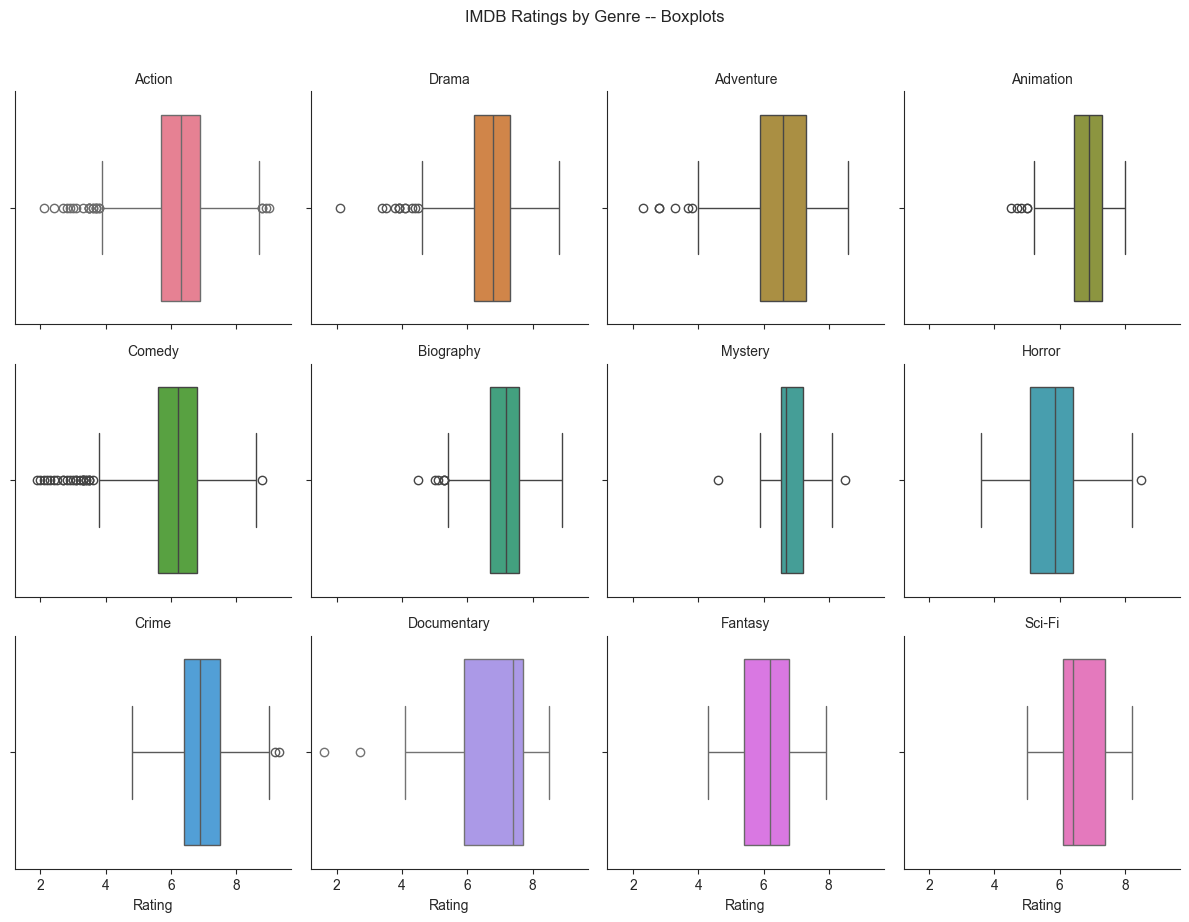

In [11]:
g = sns.FacetGrid(movies, col='genre', hue='genre', col_wrap=4, sharex=True, sharey=True)
g.map(sns.boxplot, 'rating')
g.fig.suptitle("IMDB Ratings by Genre -- Boxplots", y=1.02)
g.set_axis_labels("Rating", "")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### 5b. Histograms

Histograms show the count of movies falling into each rating bin. Useful for spotting peaks and skew.

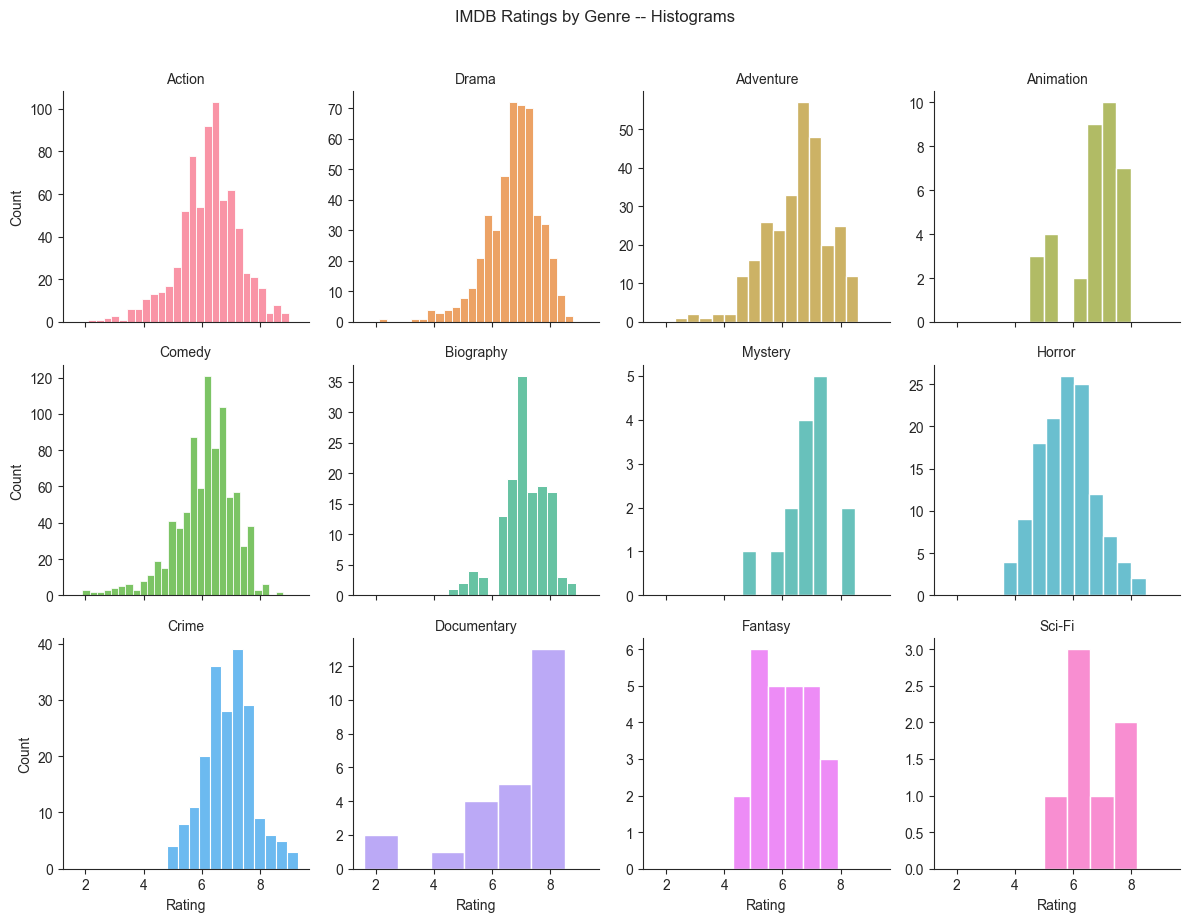

In [12]:
g = sns.FacetGrid(movies, col='genre', hue='genre', col_wrap=4, sharex=True, sharey=False)
g.map(sns.histplot, 'rating')
g.fig.suptitle("IMDB Ratings by Genre -- Histograms", y=1.02)
g.set_axis_labels("Rating", "Count")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### 5c. ECDF (Empirical Cumulative Distribution Function)

The ECDF shows what proportion of movies score at or below each rating value. Steeper sections = more movies clustered at that rating. Useful for comparing genres without assuming a bell curve.

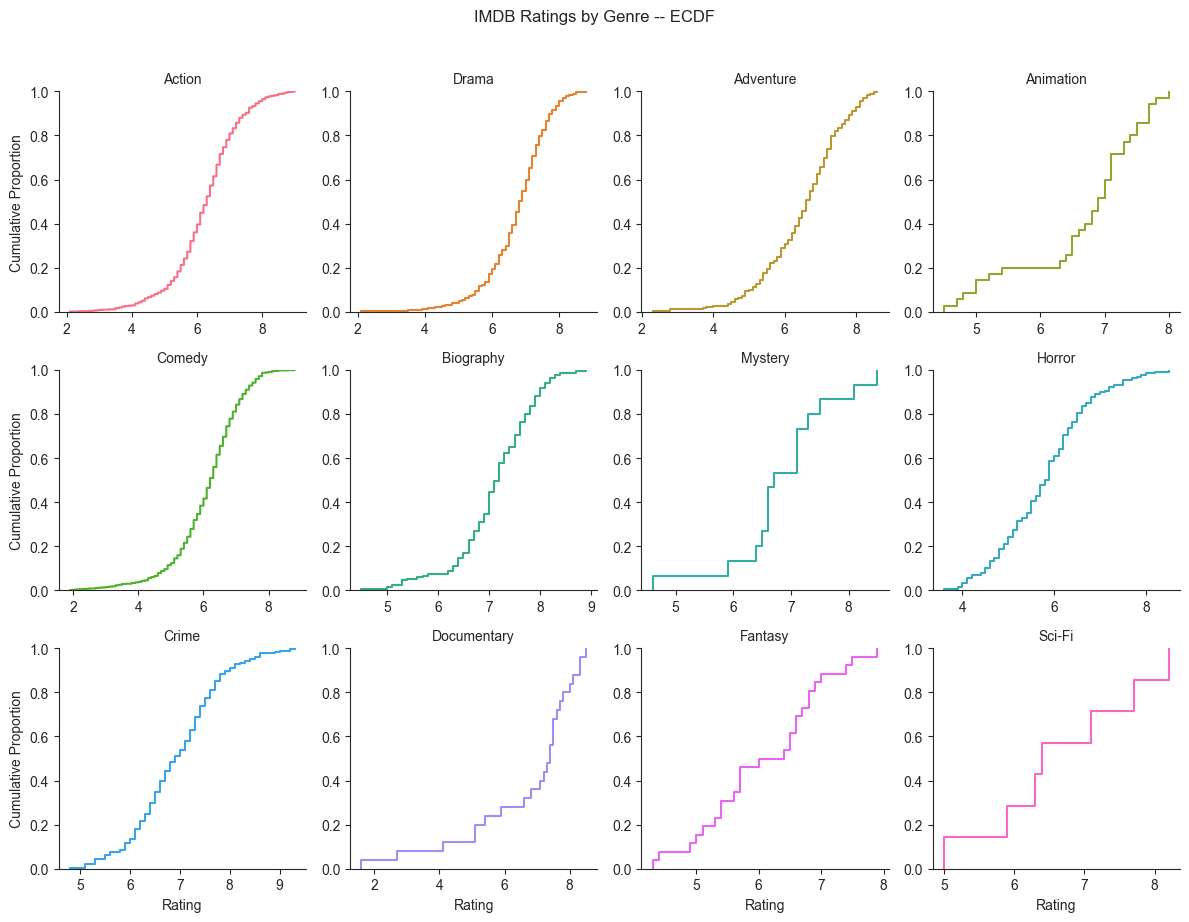

In [13]:
g = sns.FacetGrid(movies, col='genre', hue='genre', col_wrap=4, sharex=False, sharey=False)
g.map(sns.ecdfplot, 'rating')
g.fig.suptitle("IMDB Ratings by Genre -- ECDF", y=1.02)
g.set_axis_labels("Rating", "Cumulative Proportion")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### 5d. Density Plots (KDE)

Kernel Density Estimates are smoothed histograms. Higher peaks = more common ratings. Good for seeing the overall shape of each genre's rating distribution.

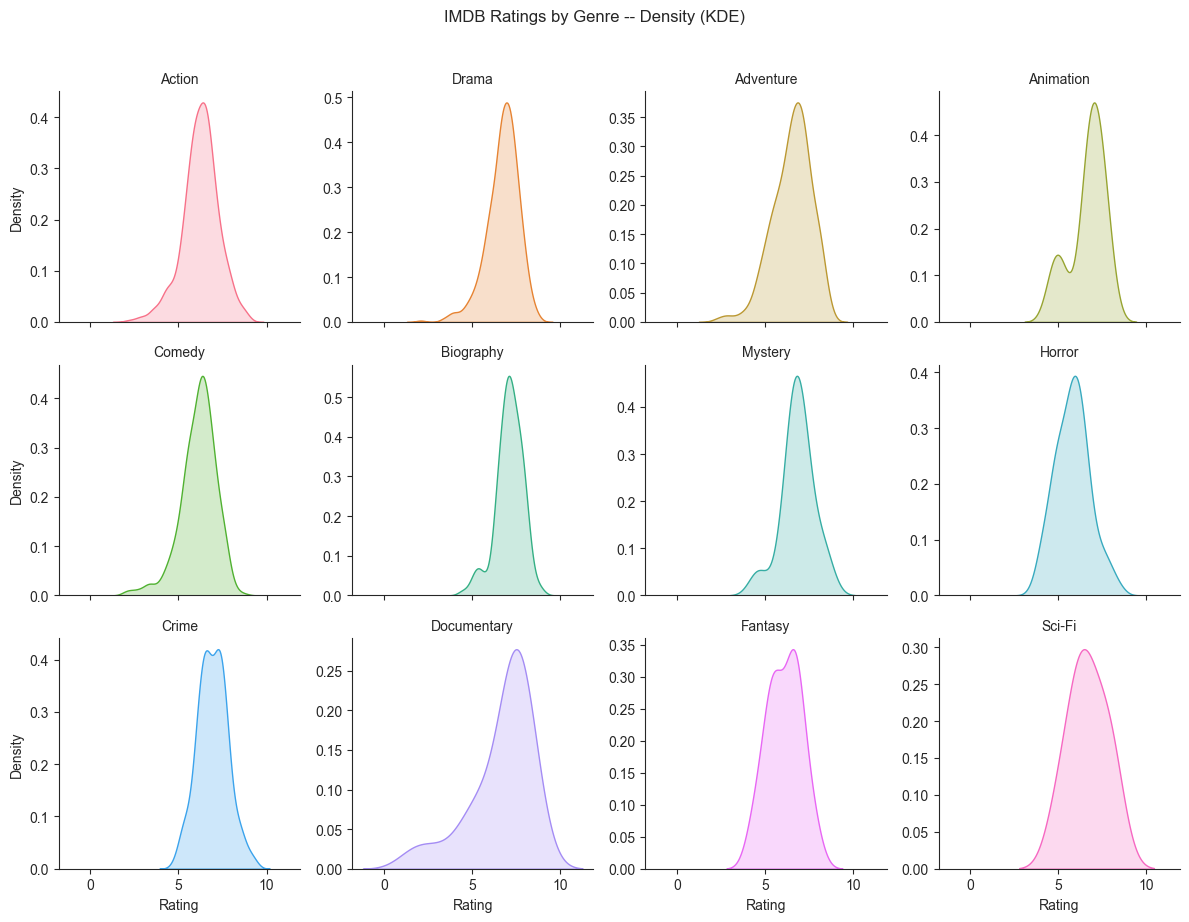

In [14]:
g = sns.FacetGrid(movies, col='genre', hue='genre', col_wrap=4, sharex=True, sharey=False)
g.map(sns.kdeplot, 'rating', fill=True)   # fill=True shades under the curve
g.fig.suptitle("IMDB Ratings by Genre -- Density (KDE)", y=1.02)
g.set_axis_labels("Rating", "Density")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

## 6. Confidence Intervals

For each genre we compute the **95% confidence interval** around the mean rating.

The formula is: `mean +/- t_critical * (sd / sqrt(n))`

- `t_critical` comes from the t-distribution (accounts for small sample sizes)
- `sd / sqrt(n)` is the **standard error** -- how uncertain we are about the mean
- Wider CI = fewer movies or more variable ratings
- If two genres' CIs overlap, we cannot confidently say their true means differ

In [16]:
genre_ci = (
    movies
    .groupby('genre')['rating']
    # Get the three ingredients we need: mean, sd, and n
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'mean_rating', 'std': 'sd_rating'})
    .assign(
        # t_critical: the multiplier for 95% CI from the t-distribution
        # df = n - 1; ppf(0.975) gives the two-tailed 95% critical value
        t_critical     = lambda x: stats.t.ppf(0.975, x['count'] - 1),

        # Standard error: sd / sqrt(n) -- decreases as sample size grows
        se_rating      = lambda x: x['sd_rating'] / np.sqrt(x['count']),

        # Margin of error: how far the CI stretches either side of the mean
        margin_of_error = lambda x: x['t_critical'] * x['se_rating'],

        # Lower and upper CI bounds
        rating_low     = lambda x: x['mean_rating'] - x['margin_of_error'],
        rating_high    = lambda x: x['mean_rating'] + x['margin_of_error'],
    )
    .sort_values('mean_rating', ascending=False)
    .round(2)
    .reset_index()
)

display(genre_ci)

,genre,mean_rating,sd_rating,count,t_critical,se_rating,margin_of_error,rating_low,rating_high
0,Biography,7.11,0.76,135,1.98,0.07,0.13,6.98,7.24
1,Crime,6.92,0.85,198,1.97,0.06,0.12,6.81,7.04
2,Mystery,6.84,0.91,15,2.14,0.23,0.50,6.34,7.34
3,Drama,6.74,0.92,484,1.96,0.04,0.08,6.66,6.82
4,Documentary,6.66,1.77,25,2.06,0.35,0.73,5.93,7.39
5,Sci-Fi,6.66,1.09,7,2.45,0.41,1.01,5.65,7.67
6,Animation,6.65,0.97,35,2.03,0.16,0.33,6.32,6.98
7,Adventure,6.51,1.11,281,1.97,0.07,0.13,6.38,6.64
8,Action,6.23,1.04,719,1.96,0.04,0.08,6.16,6.31
9,Comedy,6.11,1.02,844,1.96,0.04,0.07,6.04,6.18


## 7. Jitter Plot with Mean and CI

Each dot is one movie. The orange diamonds show the genre mean, and error bars show the 95% CI. This lets us see both the raw spread and the statistical summary simultaneously.

/var/folders/92/b0mp0v8546x1_h0np6ymywd80000gp/T/ipykernel_27502/2146543557.py:13: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/var/folders/92/b0mp0v8546x1_h0np6ymywd80000gp/T/ipykernel_27502/2146543557.py:13: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


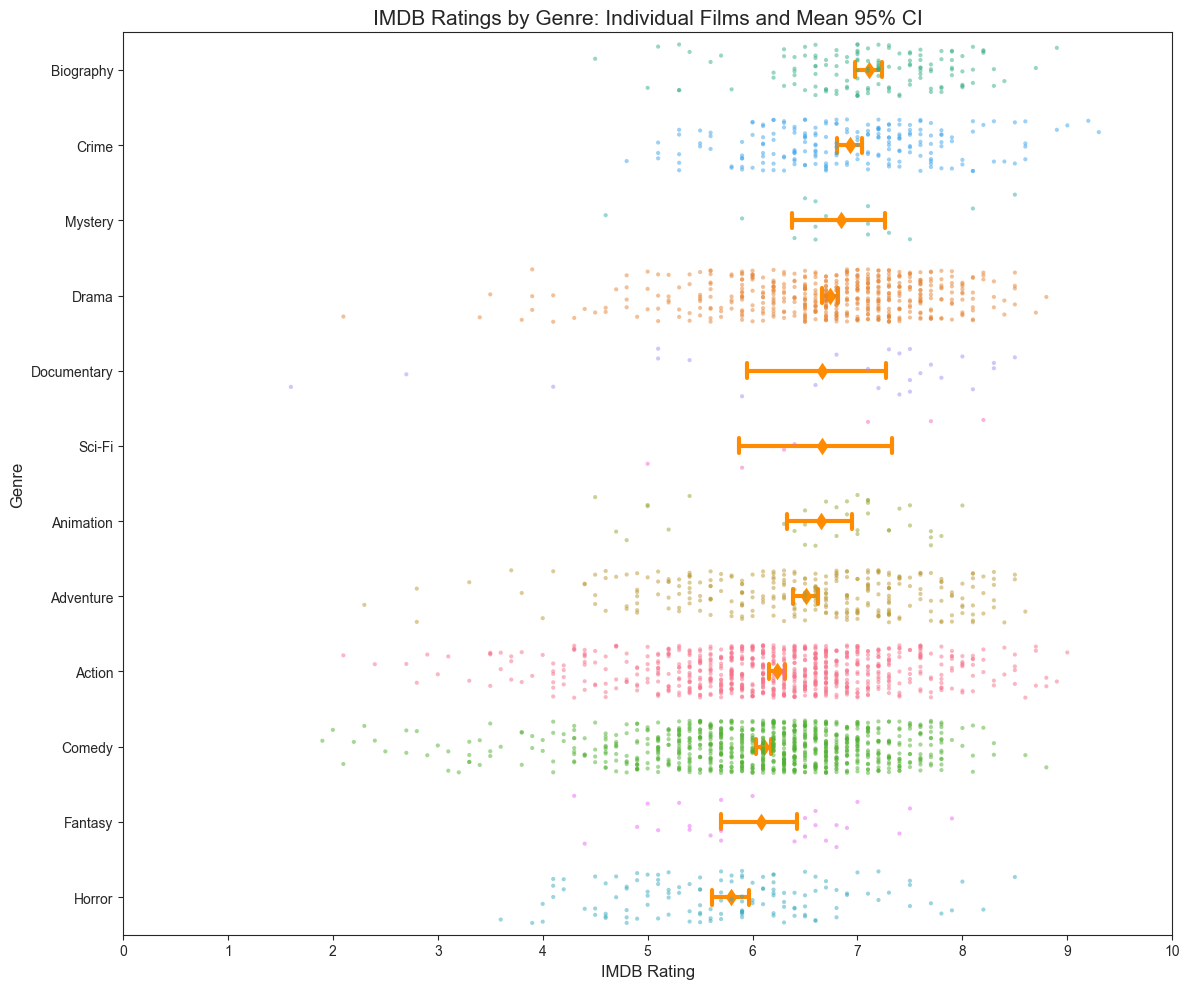

In [17]:
ordered_genres = genre_ci['genre']   # genres already sorted by mean_rating desc

fig, ax = plt.subplots(figsize=(12, 10))

# Individual movies as semi-transparent dots (jittered so they don't stack)
sns.stripplot(
    data=movies, x='rating', y='genre',
    hue='genre', order=ordered_genres,
    jitter=0.35, alpha=0.5, size=3, ax=ax
)

# Overlay mean + 95% CI as orange diamonds
sns.pointplot(
    data=movies, x='rating', y='genre',
    order=ordered_genres,
    estimator=np.mean,
    errorbar=('ci', 95),
    join=False,
    color='darkorange',
    markers='d',        # diamond marker
    scale=1.1,
    capsize=0.2,
    ax=ax
)

ax.set_title("IMDB Ratings by Genre: Individual Films and Mean 95% CI", fontsize=15)
ax.set_xlabel("IMDB Rating", fontsize=12)
ax.set_ylabel("Genre", fontsize=12)
ax.set_xticks(np.arange(0, 11, 1))
plt.tight_layout()
plt.show()

## 8. Error Bar Plot (CI Only)

A cleaner view: just the mean and 95% CI for each genre, with exact values labelled. Blue = lower bound, black = mean, red = upper bound.

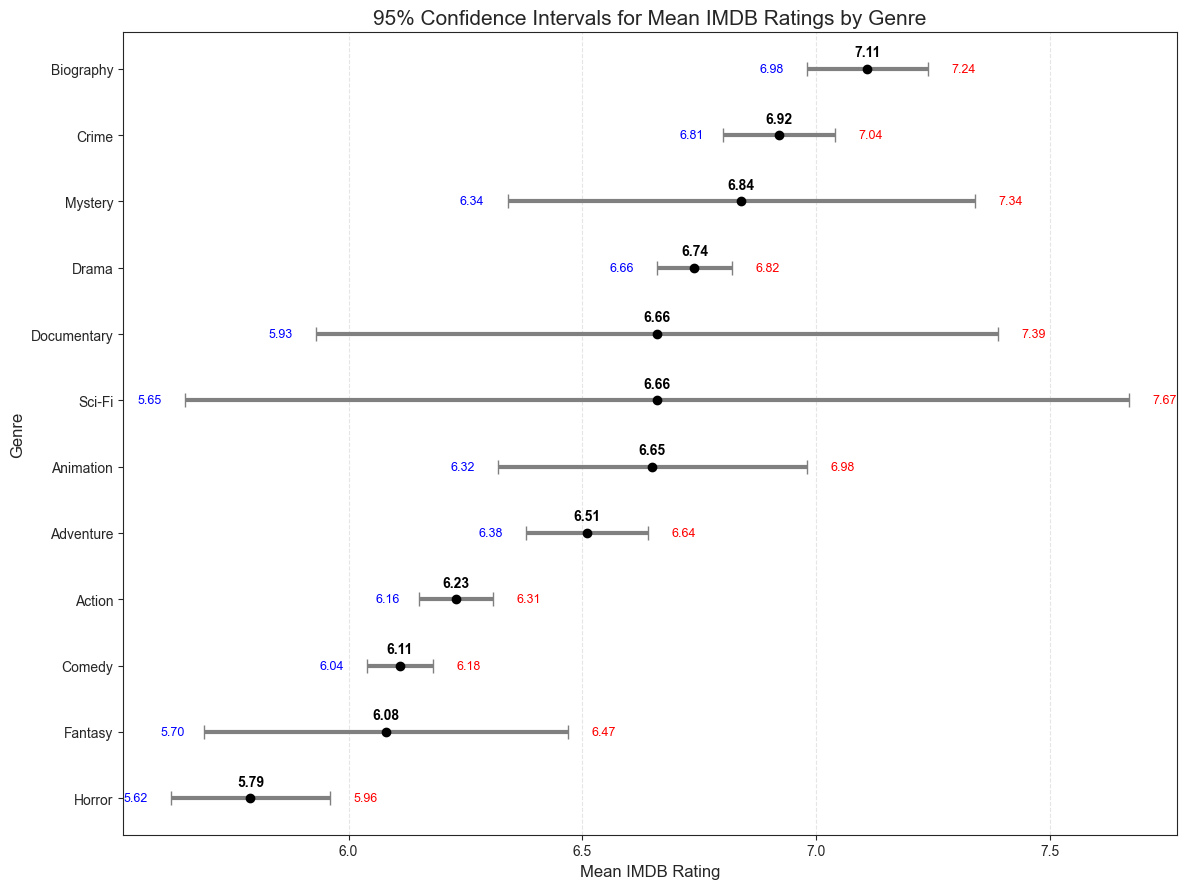

In [18]:
ci_plot = genre_ci.copy()   # already sorted descending by mean_rating

fig, ax = plt.subplots(figsize=(12, 9))

# Draw one error bar per genre
ax.errorbar(
    y=ci_plot['genre'],
    x=ci_plot['mean_rating'],
    xerr=ci_plot['margin_of_error'],
    fmt='o',          # circle for the point
    color='black',
    ecolor='gray',
    elinewidth=3,
    capsize=5
)

# Annotate with numeric values: lower (blue), mean (black bold), upper (red)
for i, row in ci_plot.iterrows():
    ax.text(row['rating_low']  - 0.05, i, f"{row['rating_low']:.2f}",
            color='blue',  ha='right',  va='center', fontsize=9)
    ax.text(row['mean_rating'],         i - 0.25, f"{row['mean_rating']:.2f}",
            color='black', ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(row['rating_high'] + 0.05, i, f"{row['rating_high']:.2f}",
            color='red',   ha='left',   va='center', fontsize=9)

ax.invert_yaxis()    # highest-rated genre at the top
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_title("95% Confidence Intervals for Mean IMDB Ratings by Genre", fontsize=15)
ax.set_xlabel("Mean IMDB Rating", fontsize=12)
ax.set_ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Interpretation Guide

| Question | Where to look |
|---|---|
| Which genres rate highest / lowest? | Sort `mean_rating` in the CI table |
| How certain are the estimates? | Width of the CI -- wider = less certain |
| Do two genres truly differ? | Overlapping CIs suggest no significant difference |
| What is the shape of each distribution? | KDE / histogram panels |
| Are there unusual films? | Dots outside whiskers in boxplots |
| Which genres have enough data? | `count` column in the CI table |

**Remember**: statistical significance (non-overlapping CIs) is not the same as practical significance. A 0.1-point difference in mean rating may be real but not meaningful to a viewer.